CELL 1 – Imports

In [1]:
# CELL 1: Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

sns.set(style="whitegrid", rc={"figure.figsize": (8, 5)})
tf.random.set_seed(42)
np.random.seed(42)


CELL 2 – Load data and basic checks

In [2]:
# CELL 2: Load dataset

df = pd.read_csv("Global_Pollution_Analysis.csv")
print(df.shape)
df.head()


(200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


CELL 3: Basic info and missing values

In [3]:
# CELL 3: Basic info and missing values

print(df.info())
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


CELL 4 – Handle missing values

In [4]:
# CELL 4: Handle missing values (numeric -> median, categorical -> mode)

df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

df_clean.isna().sum()


/tmp/ipykernel_213/3534608893.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_213/3534608893.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


CELL 5 – Label encoding for Country and Year


In [5]:
# CELL 5: Label encode categorical features

df_model = df_clean.copy()
label_encoders = {}

if "Country" in df_model.columns:
    le_country = LabelEncoder()
    df_model["Country_Encoded"] = le_country.fit_transform(df_model["Country"])
    label_encoders["Country"] = le_country

if "Year" in df_model.columns:
    le_year = LabelEncoder()
    df_model["Year_Encoded"] = le_year.fit_transform(df_model["Year"])
    label_encoders["Year"] = le_year

df_model.head()


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Year_Encoded
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,77,5
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,147,1
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,136,16
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,38,18
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,46,8


CELL 6 – Strong feature engineering

In [6]:
# CELL 6: Strong feature engineering

df_fe = df_model.copy()

# Pollution indices
pollution_cols = ["Air_Pollution_Index", "Water_Pollution_Index", "Soil_Pollution_Index"]

# 1. Total pollution index
df_fe["Total_Pollution_Index"] = df_fe[pollution_cols].sum(axis=1)

# 2. Pollution-to-energy ratio
df_fe["Pollution_to_Energy"] = df_fe["Total_Pollution_Index"] / (
    df_fe["Energy_Recovered (in GWh)"] + 1e-6
)

# 3. Waste-to-energy efficiency
df_fe["Waste_to_Energy_Efficiency"] = df_fe["Energy_Recovered (in GWh)"] / (
    df_fe["Industrial_Waste (in tons)"] + 1e-6
)

# 4. CO2 per unit energy
df_fe["CO2_per_Energy"] = df_fe["CO2_Emissions (in MT)"] / (
    df_fe["Energy_Recovered (in GWh)"] + 1e-6
)

# 5. Renewable share per energy
df_fe["Renewable_per_Energy"] = df_fe["Renewable_Energy (%)"] / (
    df_fe["Energy_Recovered (in GWh)"] + 1e-6
)

# 6. Energy recovered per capita
df_fe["Energy_Recovered_per_Capita"] = df_fe["Energy_Recovered (in GWh)"] / (
    df_fe["Population (in millions)"] + 1e-6
)

df_fe.head()


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),...,Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Year_Encoded,Total_Pollution_Index,Pollution_to_Energy,Waste_to_Energy_Efficiency,CO2_per_Energy,Renewable_per_Energy,Energy_Recovered_per_Capita
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,...,42.22,20972.96,77,5,448.92,2.838750,0.001668,0.033515,0.259960,3.745618
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,...,137.25,34850.41,147,1,264.28,0.530640,0.008849,0.012730,0.073167,3.628707
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,...,124.47,57773.15,136,16,296.67,0.606055,0.008701,0.101510,0.019162,3.932755
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,...,67.80,21837.51,38,18,441.35,3.040019,0.001939,0.061372,0.130665,2.141298
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,...,186.52,41379.37,46,8,428.24,10.605250,0.000525,0.369737,0.842001,0.216492


CELL 7 – Yearly trends (optional but good)

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh)
0,2000,197.796000,118.513000,69.283000,296.889000
1,2001,137.964444,83.933333,71.340000,288.877778
2,2002,174.661538,123.617692,75.344615,259.750769
3,2003,203.103000,133.080000,100.687000,208.139000
4,2004,171.120909,120.719091,69.959091,186.458182


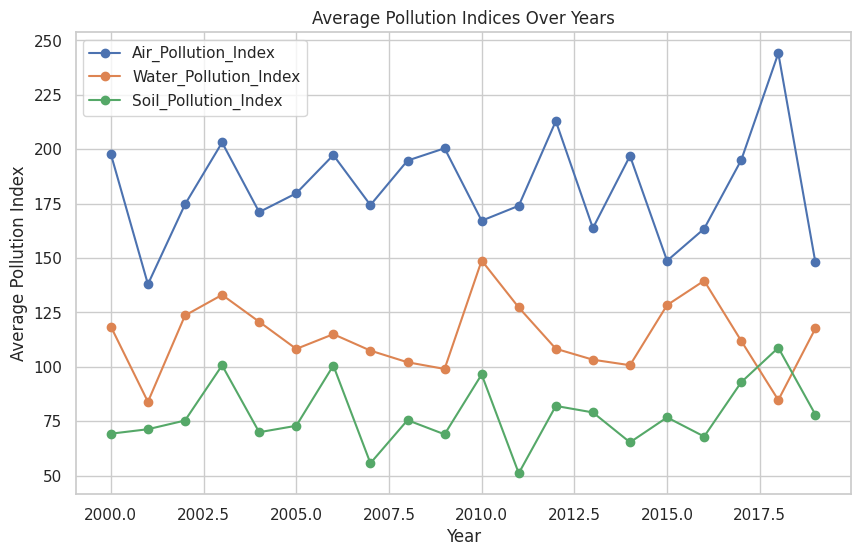

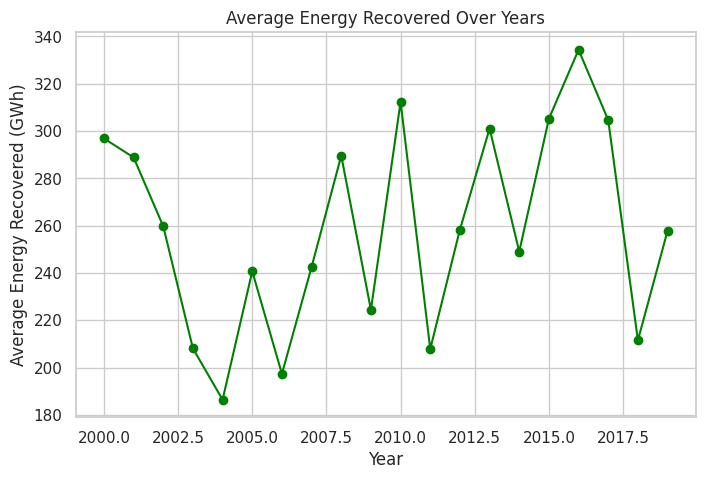

In [7]:
# CELL 7: Yearly pollution and energy trends

if "Year" in df_fe.columns:
    yearly_trends = (
        df_fe.groupby("Year")[pollution_cols + ["Energy_Recovered (in GWh)"]]
        .mean()
        .reset_index()
    )
    display(yearly_trends.head())

    plt.figure(figsize=(10, 6))
    for col in pollution_cols:
        plt.plot(yearly_trends["Year"], yearly_trends[col], marker="o", label=col)
    plt.xlabel("Year")
    plt.ylabel("Average Pollution Index")
    plt.title("Average Pollution Indices Over Years")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(yearly_trends["Year"], yearly_trends["Energy_Recovered (in GWh)"],
             marker="o", color="green")
    plt.xlabel("Year")
    plt.ylabel("Average Energy Recovered (GWh)")
    plt.title("Average Energy Recovered Over Years")
    plt.show()


CELL 8 – Feature list and scaling

In [8]:
# CELL 8: Define features and scale

engineered_cols = [
    "Total_Pollution_Index",
    "Pollution_to_Energy",
    "Waste_to_Energy_Efficiency",
    "CO2_per_Energy",
    "Renewable_per_Energy",
    "Energy_Recovered_per_Capita"
]

feature_cols = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)",
    "Plastic_Waste_Produced (in tons)",
    "Energy_Consumption_Per_Capita (in MWh)",
    "Population (in millions)",
    "GDP_Per_Capita (in USD)",
] + engineered_cols

if "Country_Encoded" in df_fe.columns:
    feature_cols.append("Country_Encoded")
if "Year_Encoded" in df_fe.columns:
    feature_cols.append("Year_Encoded")

X_all = df_fe[feature_cols].values

scaler_all = StandardScaler()
X_scaled = scaler_all.fit_transform(X_all)


CELL 9 – Correlation heatmap


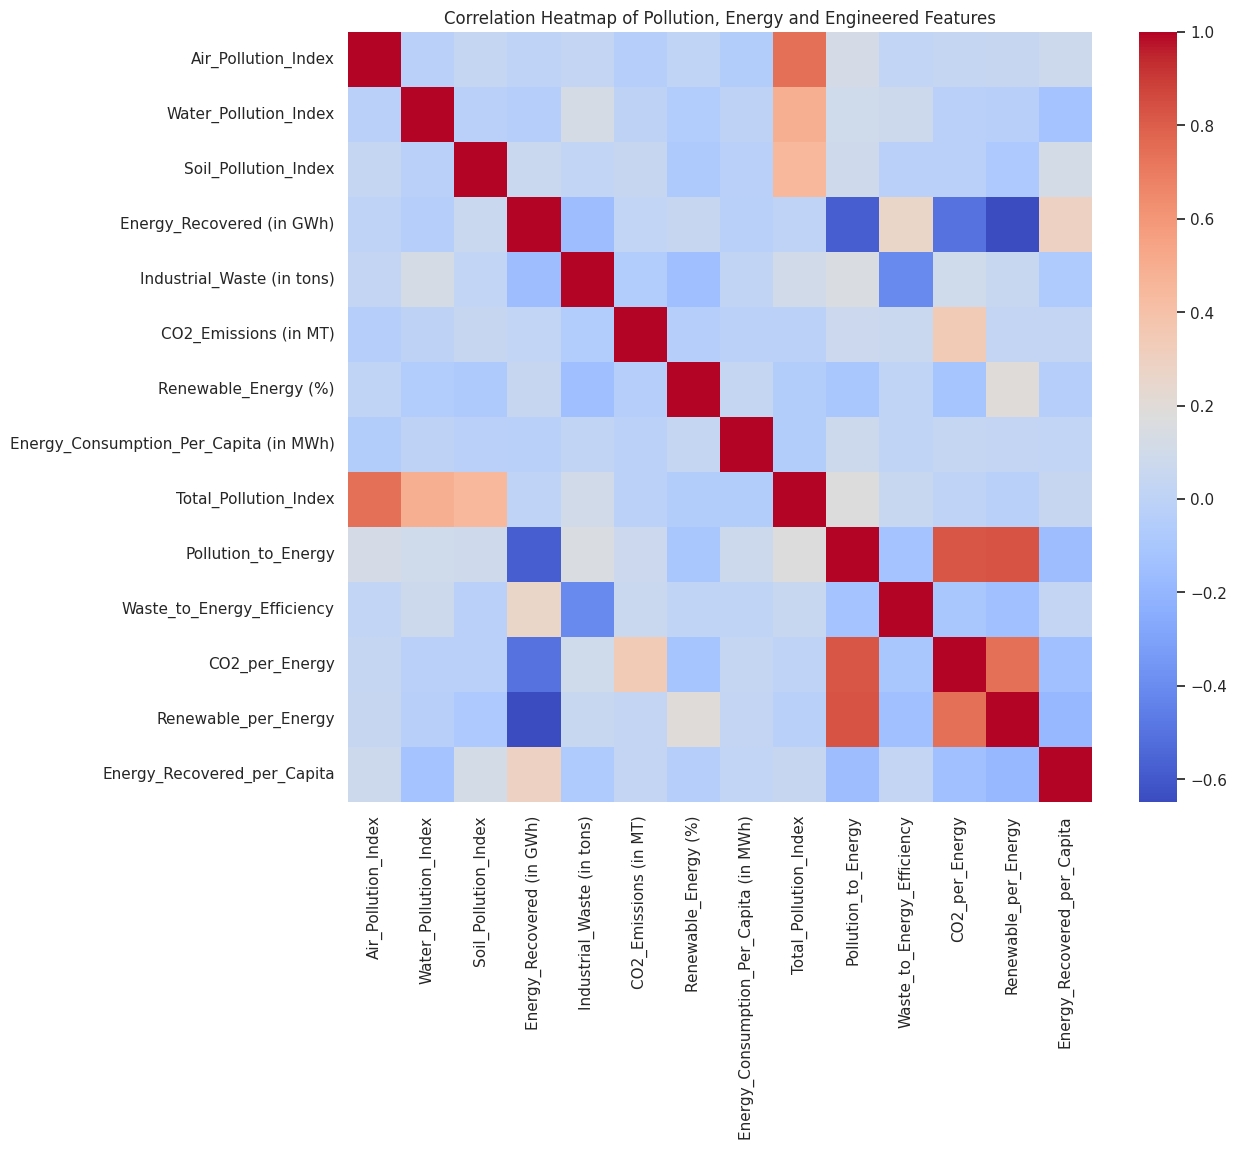

In [9]:
# CELL 9: Correlation heatmap

corr_cols = pollution_cols + [
    "Energy_Recovered (in GWh)",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)",
    "Energy_Consumption_Per_Capita (in MWh)",
] + engineered_cols

plt.figure(figsize=(12, 10))
corr = df_fe[corr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Pollution, Energy and Engineered Features")
plt.show()


CLUSTERING


CELL 10 – K-Means: Elbow method

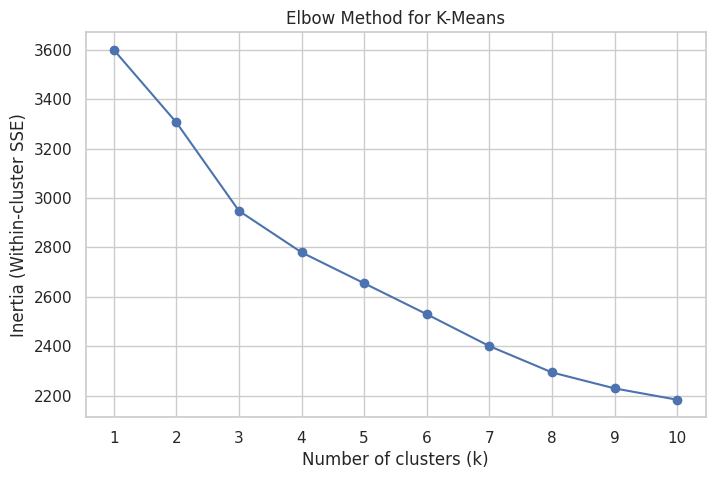

In [10]:
# CELL 10: K-Means Elbow method

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for K-Means")
plt.xticks(k_range)
plt.show()


CELL 11 – Final K-Means clustering

In [12]:
# CELL 11: Fit final K-Means (set k based on elbow, e.g., 4)

optimal_k = 4  # change if your elbow suggests another k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_fe["KMeans_Cluster"] = kmeans_final.fit_predict(X_scaled)

df_fe["KMeans_Cluster"].value_counts()


,count
KMeans_Cluster,
2,76
3,76
1,33
0,15


CELL 12 – K-Means 2D visualization and scatter

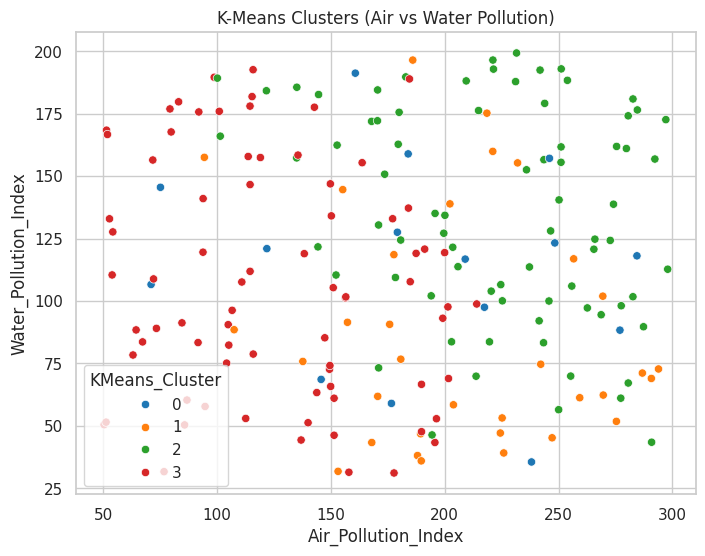

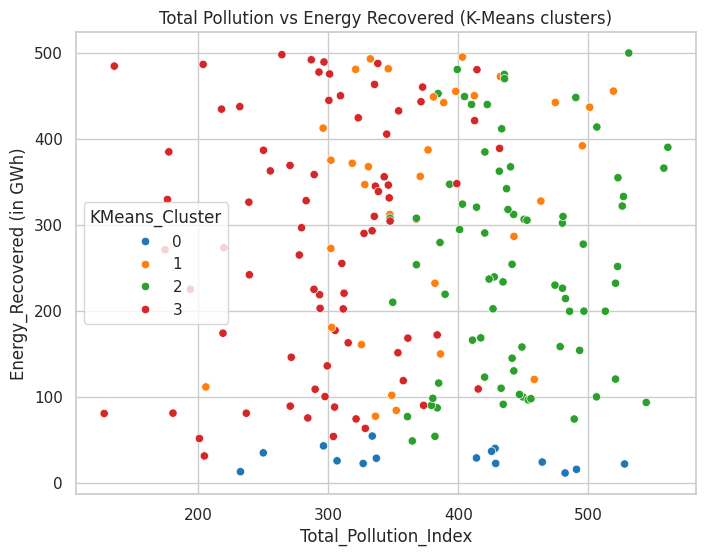

In [13]:
# CELL 12: K-Means scatter (example: Air vs Water)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_fe,
    x="Air_Pollution_Index",
    y="Water_Pollution_Index",
    hue="KMeans_Cluster",
    palette="tab10"
)
plt.title("K-Means Clusters (Air vs Water Pollution)")
plt.show()

# Total pollution vs Energy recovered
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_fe,
    x="Total_Pollution_Index",
    y="Energy_Recovered (in GWh)",
    hue="KMeans_Cluster",
    palette="tab10"
)
plt.title("Total Pollution vs Energy Recovered (K-Means clusters)")
plt.show()


CELL 13 – K-Means cluster profiles and countries

In [14]:
# CELL 13: K-Means cluster profiles

kmeans_profile = (
    df_fe.groupby("KMeans_Cluster")[
        pollution_cols
        + ["Energy_Recovered (in GWh)",
           "Waste_to_Energy_Efficiency",
           "Pollution_to_Energy",
           "Renewable_Energy (%)",
           "Energy_Recovered_per_Capita"]
    ]
    .mean()
    .round(2)
)

kmeans_profile


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh),Waste_to_Energy_Efficiency,Pollution_to_Energy,Renewable_Energy (%),Energy_Recovered_per_Capita
KMeans_Cluster,,,,,,,,
0,188.94,114.34,79.71,28.51,0.00,16.34,23.13,0.82
1,208.33,86.44,80.42,332.93,0.04,1.48,27.23,19.35
2,222.84,135.54,86.48,252.43,0.01,2.42,27.51,3.35
3,124.74,107.17,64.15,282.77,0.01,1.58,29.26,2.88


CELL 14: Countries by K-Means cluster


In [15]:
countries_kmeans = df_fe.groupby("KMeans_Cluster")["Country"].apply(list)
countries_kmeans

,Country
KMeans_Cluster,
0,"[Djibouti, Tokelau, Colombia, Zimbabwe, Pitcai..."
1,"[Swaziland, Sri Lanka, Ukraine, Mozambique, Ge..."
2,"[Hungary, Cook Islands, Congo, Central African..."
3,"[Singapore, Romania, Croatia, Northern Mariana..."


CELL 15 – Hierarchical clustering: dendrogram and labels

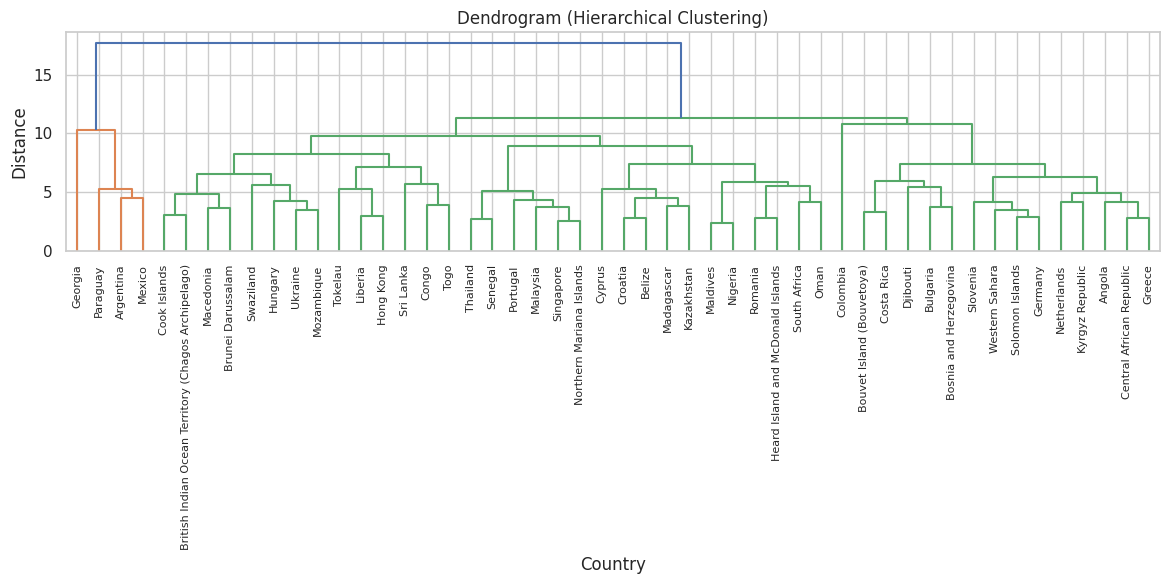

In [16]:
# CELL 15: Hierarchical clustering dendrogram (subset for readability)

subset_size = min(50, X_scaled.shape[0])
X_subset = X_scaled[:subset_size]
countries_subset = df_fe["Country"].values[:subset_size]

linked = linkage(X_subset, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=countries_subset, leaf_rotation=90)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [17]:
# CELL 16: AgglomerativeClustering with chosen number of clusters

n_clusters_hc = optimal_k  # you can change after seeing dendrogram
agg_model = AgglomerativeClustering(
    n_clusters=n_clusters_hc,
    metric="euclidean",
    linkage="ward"
)
df_fe["HC_Cluster"] = agg_model.fit_predict(X_scaled)

df_fe["HC_Cluster"].value_counts()


,count
HC_Cluster,
2,89
1,63
0,32
3,16


CELL 17 – Hierarchical visualization and profiles

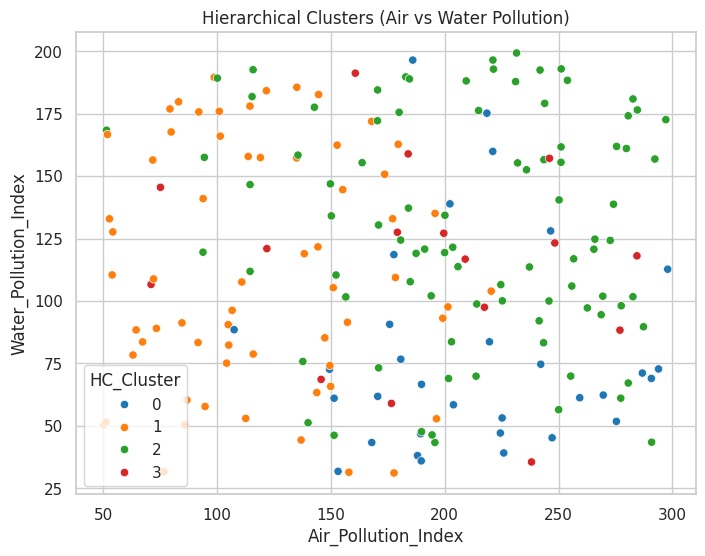

In [18]:
# CELL 17: Hierarchical clusters scatter

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_fe,
    x="Air_Pollution_Index",
    y="Water_Pollution_Index",
    hue="HC_Cluster",
    palette="tab10"
)
plt.title("Hierarchical Clusters (Air vs Water Pollution)")
plt.show()


In [20]:
# CELL 18: HC cluster profiles

hc_profile = (
    df_fe.groupby("HC_Cluster")[
        pollution_cols
        + ["Energy_Recovered (in GWh)",
           "Waste_to_Energy_Efficiency",
           "Pollution_to_Energy",
           "Renewable_Energy (%)",
           "Energy_Recovered_per_Capita"]
    ]
    .mean()
    .round(2)
)

hc_profile


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh),Waste_to_Energy_Efficiency,Pollution_to_Energy,Renewable_Energy (%),Energy_Recovered_per_Capita
HC_Cluster,,,,,,,,
0,213.34,79.18,76.68,308.64,0.03,1.63,28.96,19.46
1,118.54,113.16,63.06,263.22,0.01,1.73,25.53,3.51
2,211.20,129.31,85.81,282.63,0.01,2.07,29.74,3.00
3,189.60,115.14,77.10,29.78,0.00,15.79,23.63,0.85


In [21]:
# CELL 19: Compare K-Means vs HC for some countries

comparison_table = df_fe[["Country", "KMeans_Cluster", "HC_Cluster"]].head(30)
comparison_table


,Country,KMeans_Cluster,HC_Cluster
0,Hungary,2,2
1,Singapore,3,1
2,Romania,3,1
3,Cook Islands,2,2
4,Djibouti,0,3
5,Croatia,3,0
6,Congo,2,2
7,Central African Republic,2,2
8,Swaziland,1,0
9,Sri Lanka,1,2


CELL 20 – PCA visualization of clusters

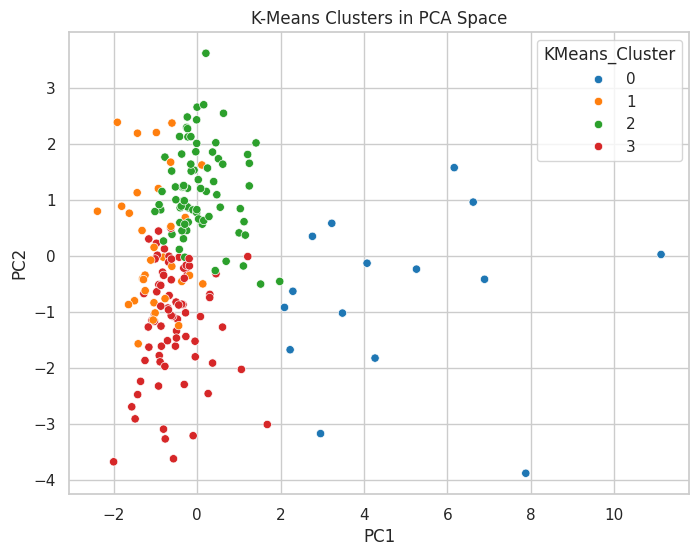

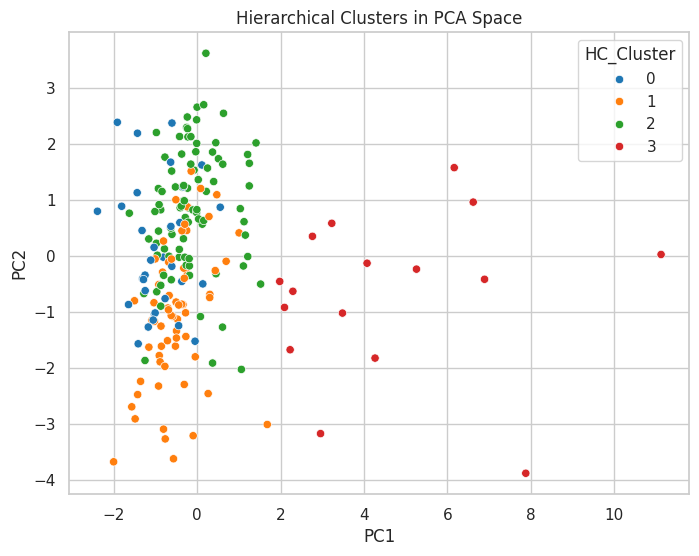

In [22]:
# CELL 20: PCA and cluster visualization

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["KMeans_Cluster"] = df_fe["KMeans_Cluster"]
df_pca["HC_Cluster"] = df_fe["HC_Cluster"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2",
                hue="KMeans_Cluster", palette="tab10")
plt.title("K-Means Clusters in PCA Space")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2",
                hue="HC_Cluster", palette="tab10")
plt.title("Hierarchical Clusters in PCA Space")
plt.show()


PREDICTION: NN vs Linear Regression


CELL 21 – Train–test split and scaling for prediction

In [23]:
# CELL 21: Train-test split for prediction

target_col = "Energy_Recovered (in GWh)"

X = df_fe[feature_cols].values
y = df_fe[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_pred = StandardScaler()
X_train_scaled = scaler_pred.fit_transform(X_train)
X_test_scaled = scaler_pred.transform(X_test)


CELL 22 – Baseline linear regression

In [24]:
# CELL 22: Baseline Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lr = lin_reg.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"R2:  {r2_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")


Linear Regression Performance:
R2:  0.5118
MSE: 11806.2607
MAE: 88.6783


CELL 23 – Helper function for NN configs

In [25]:
# CELL 23: Helper to build and evaluate NN with different hyperparameters

def build_and_evaluate_nn(hidden_layers, lr, dropout_rate=None, l2_reg=None, epochs=100):
    reg = regularizers.l2(l2_reg) if l2_reg else None

    model = Sequential()
    model.add(Dense(hidden_layers[0],
                    activation="relu",
                    input_shape=(X_train_scaled.shape[1],),
                    kernel_regularizer=reg))
    if dropout_rate:
        model.add(Dropout(dropout_rate))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu", kernel_regularizer=reg))
        if dropout_rate:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="linear"))

    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="mse",
                  metrics=["mae"])

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=16,
        verbose=0
    )

    y_pred = model.predict(X_test_scaled).flatten()
    return {
        "model": model,
        "history": history,
        "r2": r2_score(y_test, y_pred),
        "mse": mean_squared_error(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
    }


CELL 24 – Run several NN configurations (simple “grid”)

In [26]:
# CELL 24: Simple hyperparameter search over a few NN configs

configs = [
    {"name": "small_no_reg",   "hidden_layers": [32, 16],    "lr": 0.001, "dropout": None, "l2": None,   "epochs": 100},
    {"name": "medium_dropout", "hidden_layers": [64, 32],    "lr": 0.001, "dropout": 0.2,  "l2": None,   "epochs": 120},
    {"name": "medium_l2",      "hidden_layers": [64, 32],    "lr": 0.0005,"dropout": None, "l2": 1e-4,   "epochs": 120},
    {"name": "deep_l2_drop",   "hidden_layers": [64, 32,16], "lr": 0.0005,"dropout": 0.2,  "l2": 1e-4,   "epochs": 150},
]

nn_results = []
for cfg in configs:
    res = build_and_evaluate_nn(
        hidden_layers=cfg["hidden_layers"],
        lr=cfg["lr"],
        dropout_rate=cfg["dropout"],
        l2_reg=cfg["l2"],
        epochs=cfg["epochs"]
    )
    res["name"] = cfg["name"]
    nn_results.append(res)
    print(cfg["name"], "-> R2:", round(res["r2"], 4),
          "MSE:", round(res["mse"], 4), "MAE:", round(res["mae"], 4))

nn_comp = pd.DataFrame([
    {"Config": r["name"], "R2": r["r2"], "MSE": r["mse"], "MAE": r["mae"]}
    for r in nn_results
])
nn_comp


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
small_no_reg -> R2: 0.8006 MSE: 4822.5477 MAE: 52.9345


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
medium_dropout -> R2: 0.877 MSE: 2973.3225 MAE: 43.6482


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


medium_l2 -> R2: 0.7817 MSE: 5278.3181 MAE: 58.5303
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
deep_l2_drop -> R2: 0.8759 MSE: 3002.1033 MAE: 43.2752


,Config,R2,MSE,MAE
0,small_no_reg,0.800575,4822.547661,52.934495
1,medium_dropout,0.877045,2973.322544,43.648236
2,medium_l2,0.781727,5278.318125,58.530300
3,deep_l2_drop,0.875855,3002.103267,43.275185


CELL 25 – Pick best NN and plot its training curve

Best NN config: medium_dropout
R2: 0.8770, MSE: 2973.3225, MAE: 43.6482


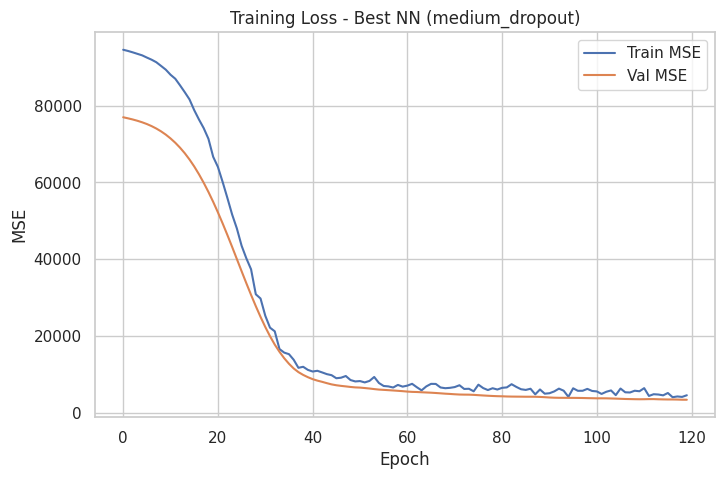

In [27]:
# CELL 25: Choose best NN (highest R2) and inspect training history

best_res = max(nn_results, key=lambda r: r["r2"])
best_model = best_res["model"]
best_history = best_res["history"]

print("Best NN config:", best_res["name"])
print(f"R2: {best_res['r2']:.4f}, MSE: {best_res['mse']:.4f}, MAE: {best_res['mae']:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(best_history.history["loss"], label="Train MSE")
plt.plot(best_history.history["val_loss"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title(f"Training Loss - Best NN ({best_res['name']})")
plt.legend()
plt.show()


CELL 26 – Actual vs predicted (best NN)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


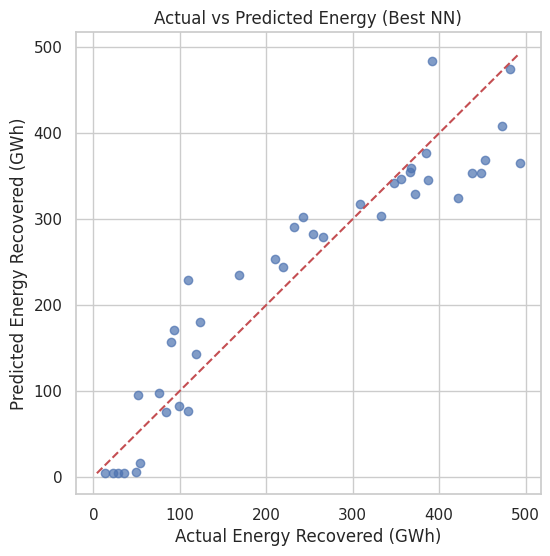

In [28]:
# CELL 26: Actual vs predicted plot for best NN

y_pred_best = best_model.predict(X_test_scaled).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7)
plt.xlabel("Actual Energy Recovered (GWh)")
plt.ylabel("Predicted Energy Recovered (GWh)")
plt.title("Actual vs Predicted Energy (Best NN)")
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.show()


CELL 27 – Final model comparison table

In [29]:
# CELL 27: Compare Linear Regression and NNs

comparison = pd.DataFrame({
    "Model": ["Linear Regression"] + [r["name"] for r in nn_results],
    "R2":    [r2_lr] + [r["r2"] for r in nn_results],
    "MSE":   [mse_lr] + [r["mse"] for r in nn_results],
    "MAE":   [mae_lr] + [r["mae"] for r in nn_results],
})

comparison


,Model,R2,MSE,MAE
0,Linear Regression,0.511780,11806.260678,88.678347
1,small_no_reg,0.800575,4822.547661,52.934495
2,medium_dropout,0.877045,2973.322544,43.648236
3,medium_l2,0.781727,5278.318125,58.530300
4,deep_l2_drop,0.875855,3002.103267,43.275185


CELL 28 – Simple cluster-based energy insight

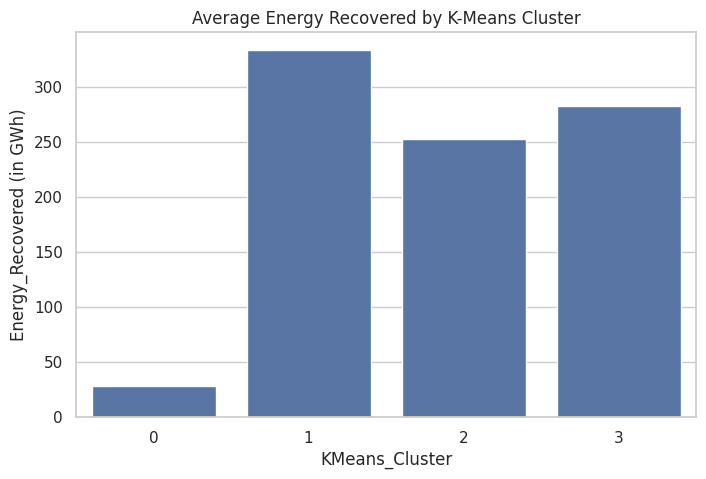

,KMeans_Cluster,Energy_Recovered (in GWh)
0,0,28.507333
1,1,332.934545
2,2,252.433947
3,3,282.767237


In [30]:
# CELL 28: Average energy recovered per K-Means cluster

cluster_energy = (
    df_fe.groupby("KMeans_Cluster")["Energy_Recovered (in GWh)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_energy, x="KMeans_Cluster", y="Energy_Recovered (in GWh)")
plt.title("Average Energy Recovered by K-Means Cluster")
plt.show()

cluster_energy
